In [34]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/processed/cleaned_data.csv')


df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']

df['Wear_warning'] = np.where(df['Tool wear [min]'] > 200, 1, 0)

df.describe()
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Temp_diff,Power,Wear_warning
0,1,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0
1,0,298.2,308.7,1408,46.3,3,0,10.5,65190.4,0
2,0,298.1,308.5,1498,49.4,5,0,10.4,74001.2,0
3,0,298.2,308.6,1433,39.5,7,0,10.4,56603.5,0
4,0,298.2,308.7,1408,40.0,9,0,10.5,56320.0,0


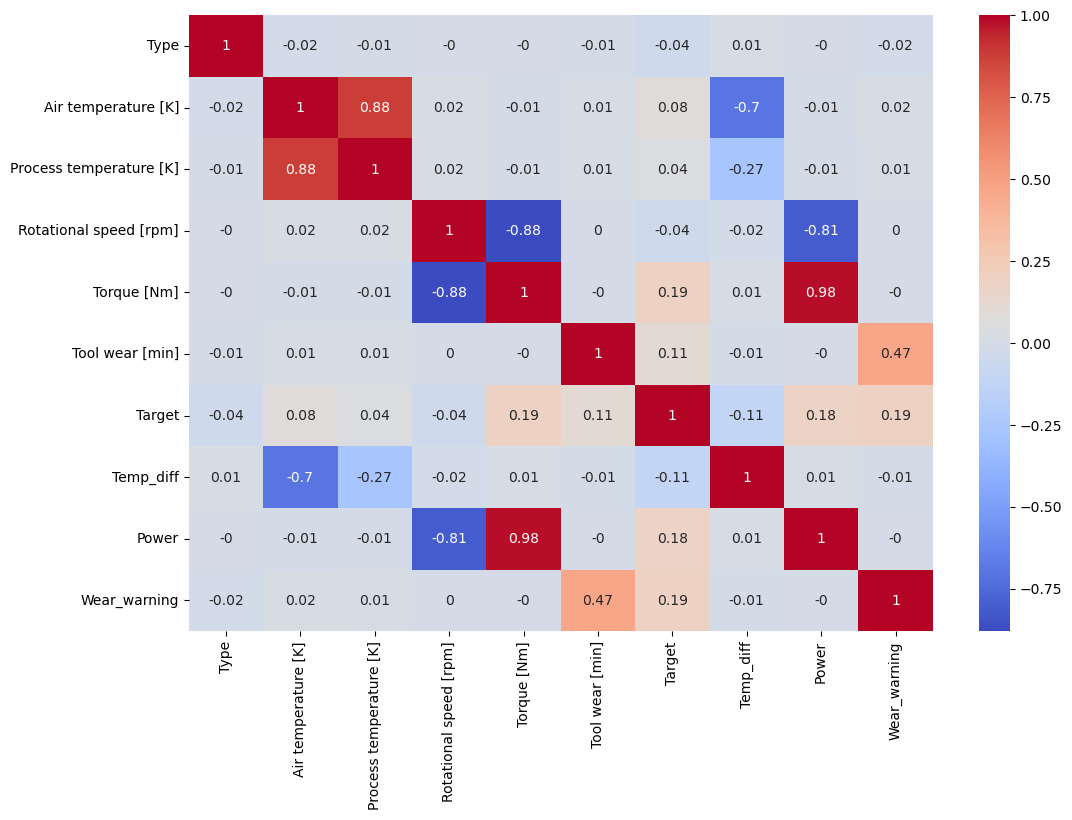

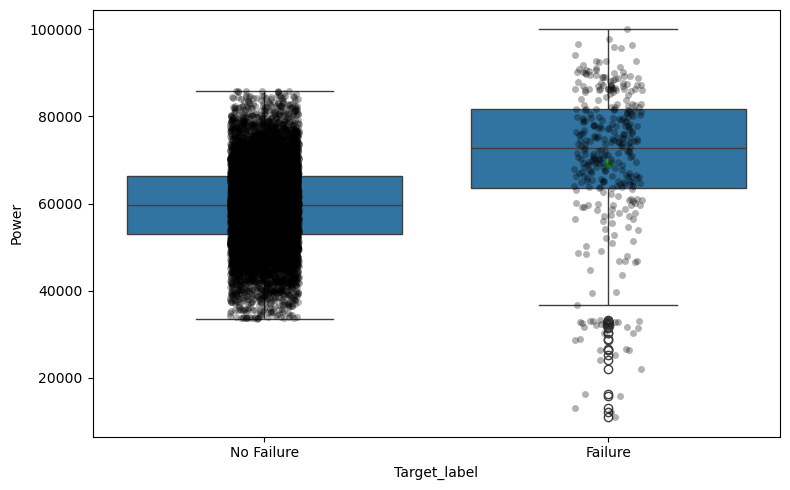

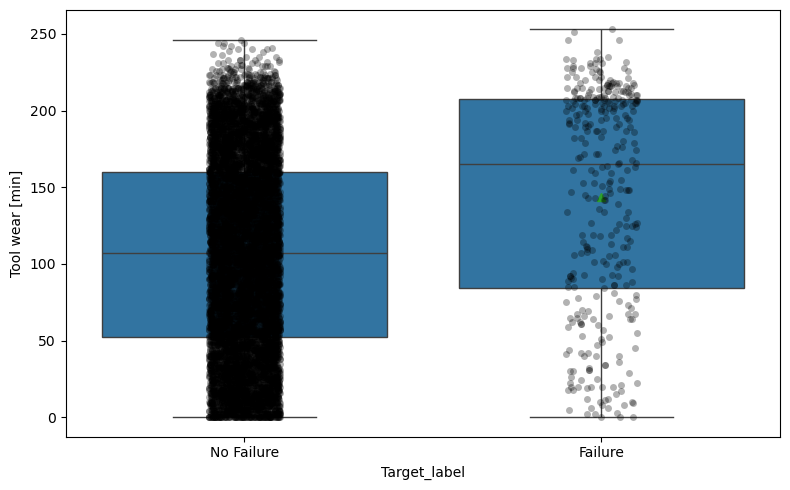

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

df['Target_label'] = df['Target'].map({0 : 'No Failure', 1 : 'Failure'})

plt.figure(figsize=(8, 5))
sns.boxplot(x='Target_label', y='Power', data=df, showmeans=True)
sns.stripplot(x='Target_label', y='Power', data=df, color='black', alpha = 0.3)
plt.tight_layout()
plt.show()      

plt.figure(figsize=(8, 5))
sns.boxplot(x='Target_label', y='Tool wear [min]', data=df, showmeans=True)
sns.stripplot(x='Target_label', y='Tool wear [min]', data=df, color='black', alpha = 0.3)
plt.tight_layout()
plt.show()      
